<a href="https://colab.research.google.com/github/eshhha/adult_income_predictions/blob/main/Adult_Income_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#LIBRARIES

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

#READ DATASET

In [36]:
filepath = '/content/drive/MyDrive/AI ML Course/Data/adult.csv'
df_adult = pd.read_csv(filepath)
df_adult

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


#EDA(Exploratory Data Analysis)

In [37]:
# Check the number of rows and columns in the dataset
df_adult.shape

(48842, 15)

In [38]:
# Display summary statistics of the numerical columns
df_adult.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [39]:
# Display information about the DataFrame
df_adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [40]:
# Count the occurrences of each unique row in the DataFrame
df_adult.value_counts()

age  workclass  fnlwgt  education     educational-num  marital-status      occupation         relationship   race   gender  capital-gain  capital-loss  hours-per-week  native-country  income
25   Private    308144  Bachelors     13               Never-married       Craft-repair       Not-in-family  White  Male    0             0             40              Mexico          <=50K     3
                195994  1st-4th       2                Never-married       Priv-house-serv    Not-in-family  White  Female  0             0             40              Guatemala       <=50K     3
21   Private    243368  Preschool     1                Never-married       Farming-fishing    Not-in-family  White  Male    0             0             50              Mexico          <=50K     3
39   Private    184659  HS-grad       9                Married-civ-spouse  Machine-op-inspct  Husband        White  Male    0             0             40              United-States   <=50K     2
45   Private    82797   Bachelors     13               Married-civ-spouse  Exec-managerial    Husband        White  Male    0             0             45              United-States   >50K      2
                                                                                                                                                                                                 ..
31   Private    156464  10th          6                Divorced            Other-service      Not-in-family  White  Male    0             0             40              United-States   <=50K     1
                        Bachelors     13               Never-married       Prof-specialty     Own-child      White  Male    0             0             25              United-States   <=50K     1
                156493  HS-grad       9                Never-married       Prof-specialty     Own-child      White  Male    0             0             40              United-States   <=50K     1
                        Some-college  10               Married-civ-spouse  Exec-managerial    Husband        White  Male    0             0             40              United-States   >50K      1
                152940  Some-college  10               Married-civ-spouse  Craft-repair       Husband        White  Male    0             0             40              United-States   <=50K     1
Name: count, Length: 48790, dtype: int64

In [41]:
# Count the total number of duplicate rows in the DataFrame
df_adult.duplicated().sum()

np.int64(52)

In [42]:
# Count the number of missing values in each column
df_adult.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


##PLOTS

In [43]:
# collecting numerical columns
num_cols = []
# collecting categorical columns
cat_cols = []

In [44]:
# Select the names of all numerical columns (integer and float data types)
num_cols = df_adult.select_dtypes(include=['int','float']).columns
# Select the names of all categorical columns (object and boolean data types)
cat_cols = df_adult.select_dtypes(include=['object','bool']).columns

In [45]:
# Display the names of the numerical columns
num_cols

Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

In [46]:
# Display the names of the categorical columns
cat_cols

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country', 'income'],
      dtype='object')

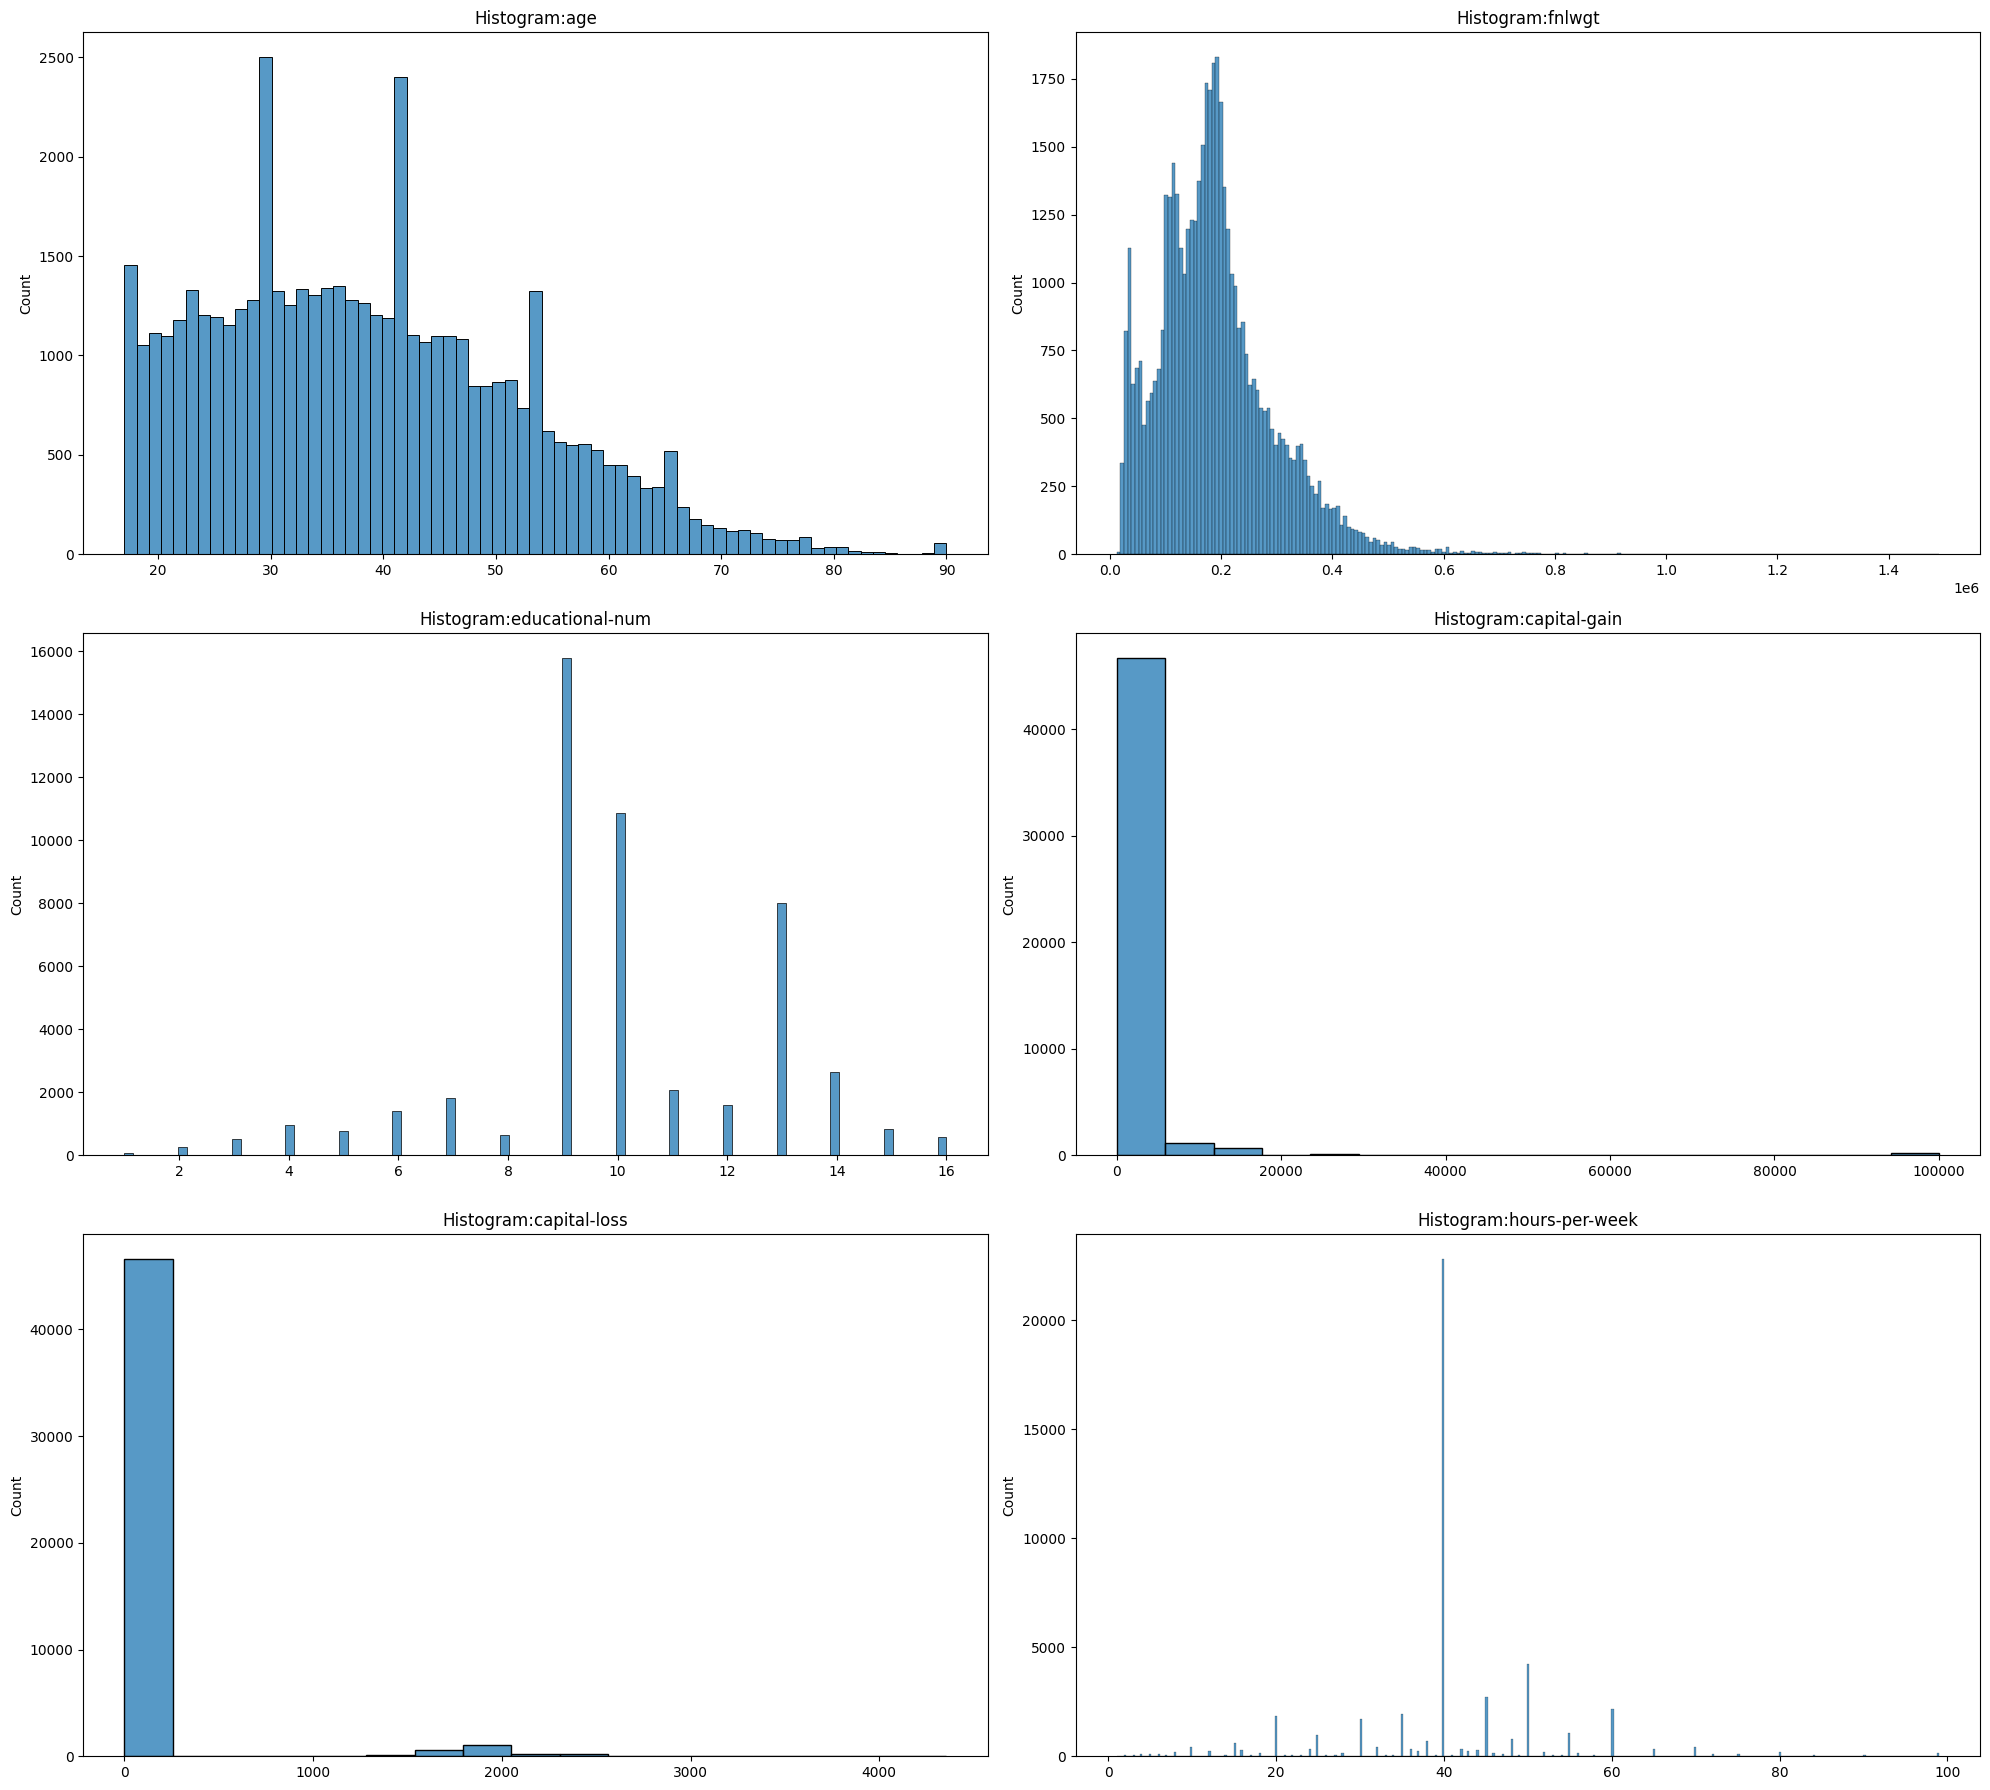

In [47]:
# Create histograms for each numerical column to understand the distribution of values
plt.figure(figsize=(20,18))

for i,col in enumerate(num_cols):
  plt.subplot(3,2,i+1)
  sns.histplot(df_adult[col])
  plt.title(f'Histogram:{col}')
  plt.xlabel('')

plt.tight_layout()
plt.show()

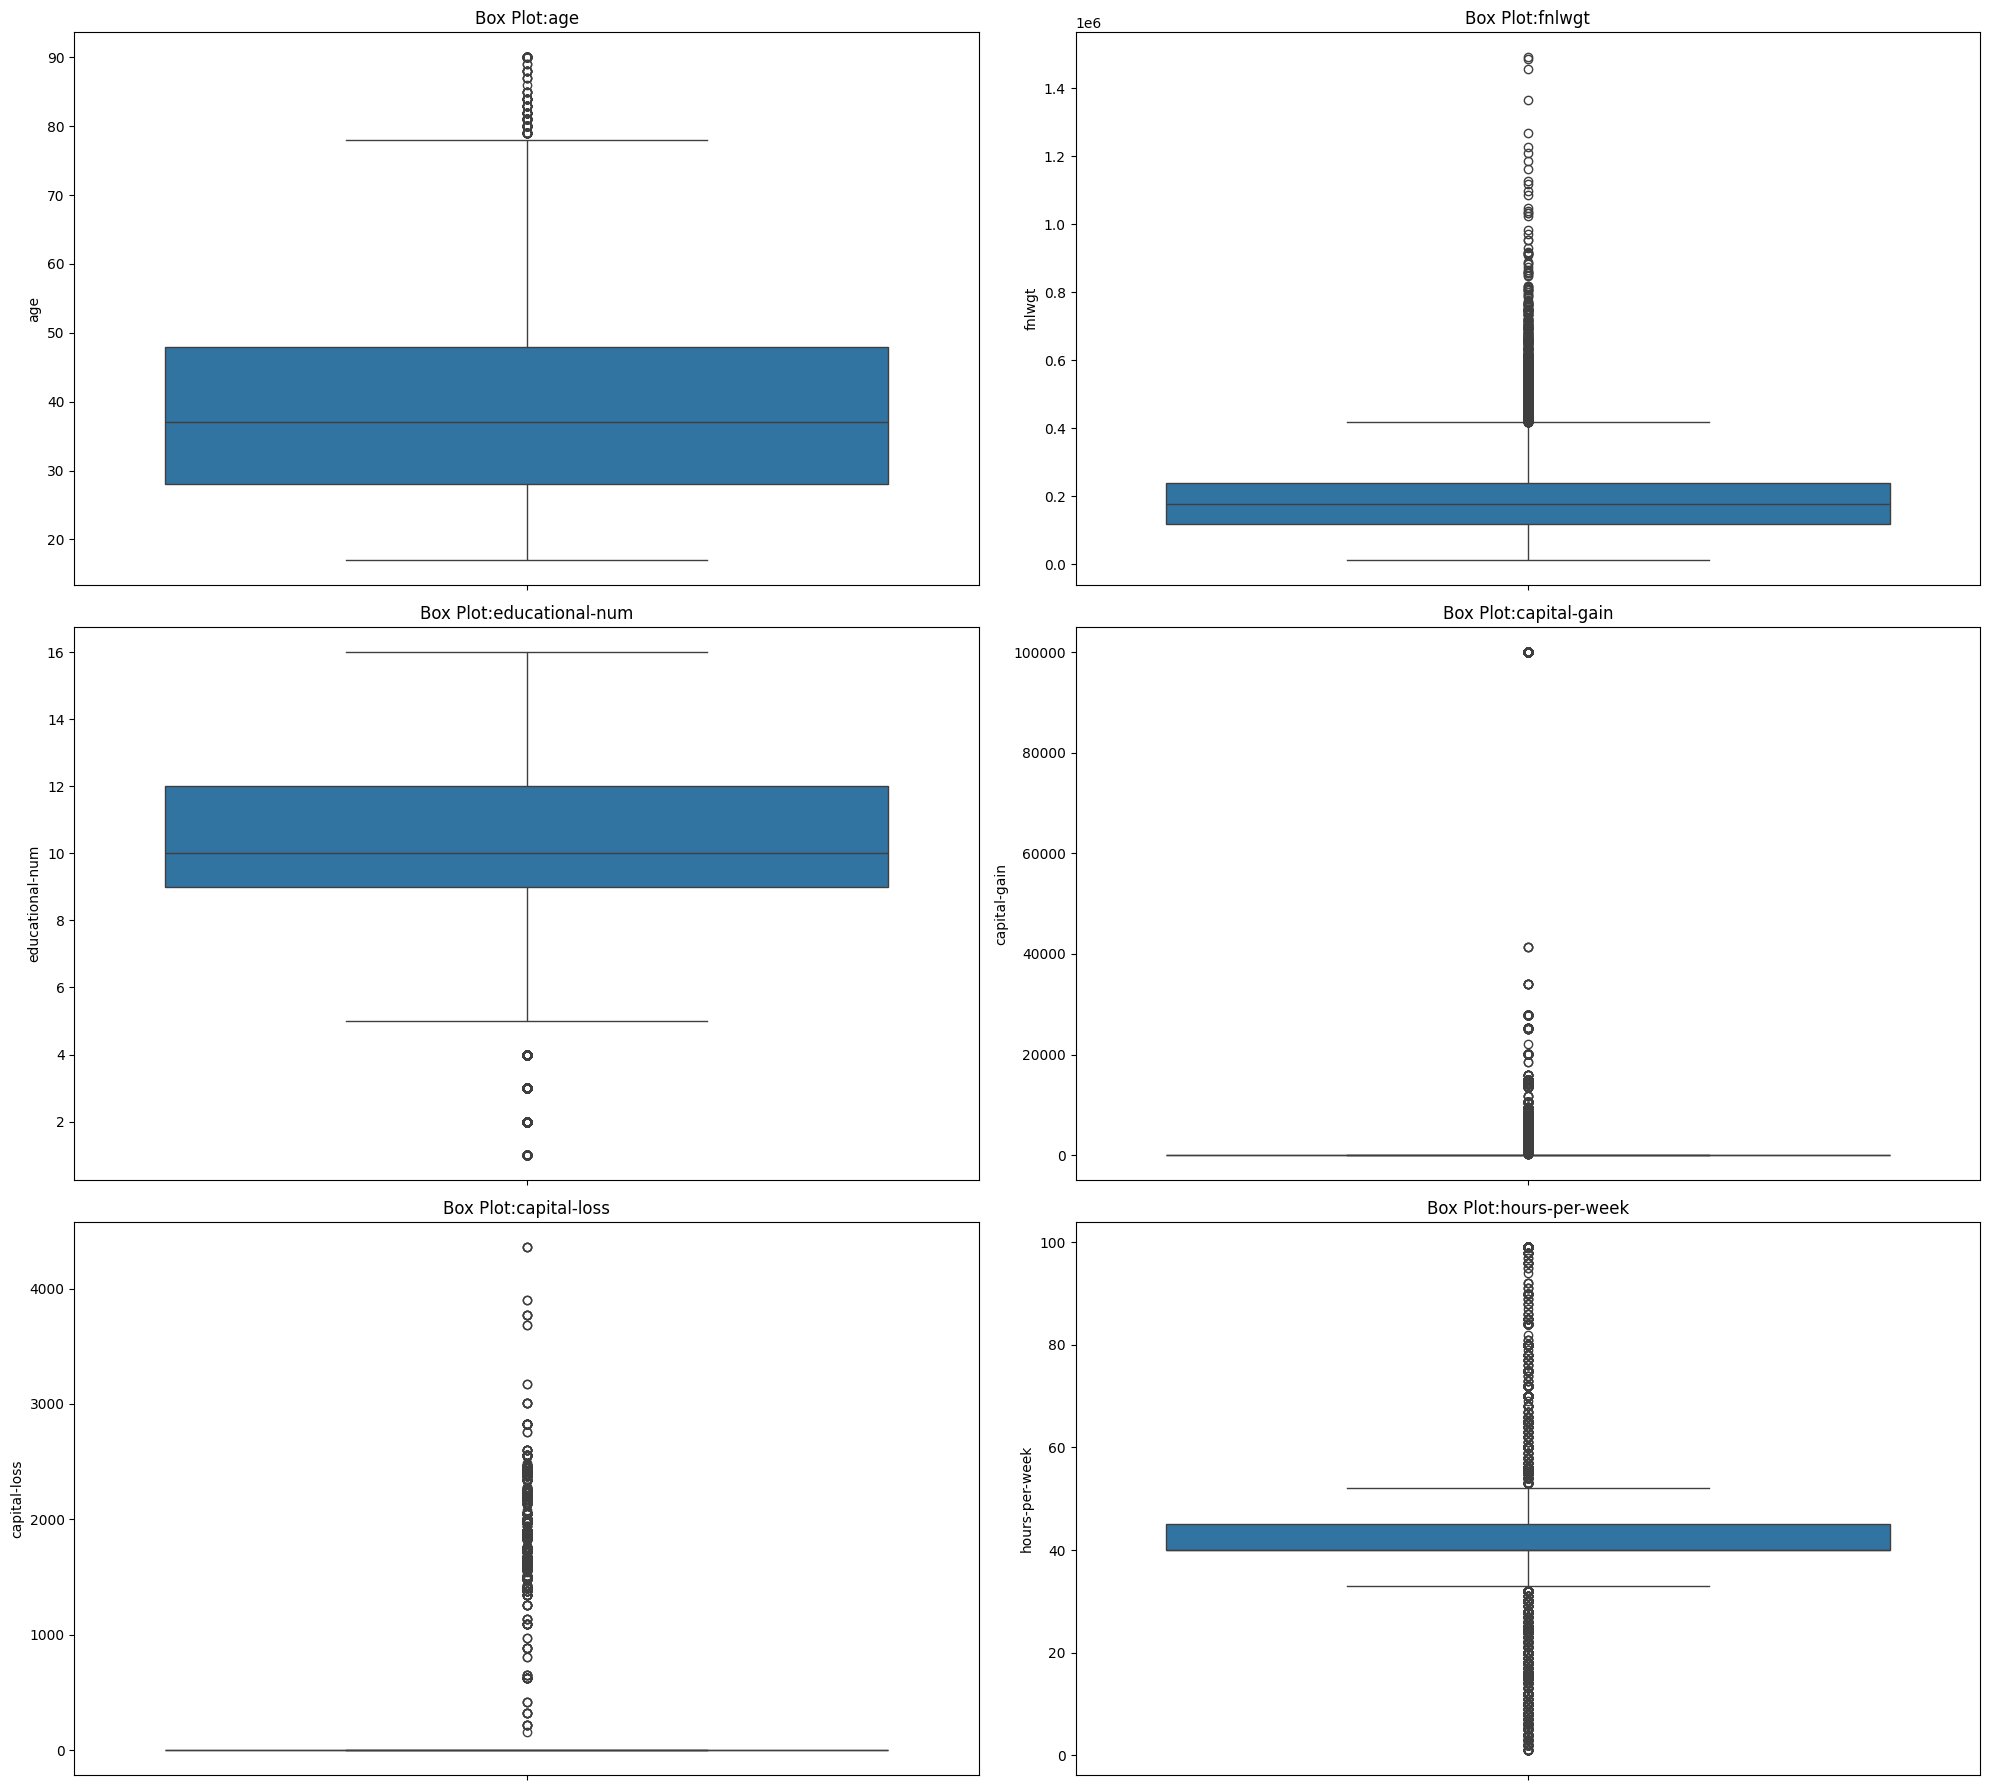

In [48]:
# Create box plots for all numerical features to detect potential outliers
plt.figure(figsize=(20,18))

for i,col in enumerate(num_cols):
  plt.subplot(3,2,i+1)
  sns.boxplot(df_adult[col])
  plt.title(f'Box Plot:{col}')
  plt.xlabel('')

plt.tight_layout()
plt.show()

#PREPROCESSING

##Data Cleaning

##Missing Value Handling

##Outlier Handling

##Duplication Removal

#TRANSFORMATIONS

##Encoding

##Scaling